# **데이터**

In [ ]:
!pip uninstall numpy scikit-surprise -y
!pip install numpy==1.23.5
!pip install scikit-surprise

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 39.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.23.5 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.23.5 which is incompatible.
xarray 2025.3.1 requires numpy>=1.24, but you have numpy 1.23.5 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.23.5 which is incompatible.
bigframes 2.4.0 requires numpy>=1.24.0, but you have numpy 1.23.5 which is incompatible.
blosc2 3.3.2 requires numpy>=1.26, but you have numpy 1.23.5 which is incompatible.
chex 0.1.89 requires numpy>=1.24.1, but you have numpy 1.23.5 which is incompatible.
treescope 0.1.9 requires numpy>=

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 3.5 MB/s eta 0:00:00
  Installing build dependencies ... canceled
ERROR: Operation cancelled by user
^C


In [ ]:
!pip install scikit-surprise

  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp311-cp311-linux_x86_64.whl size=2463302 sha256=beeeec6f01eb5faa54cfb6d61817ab562c1c39e35308f6c62ead0c3bc453c5ec
  Stored in directory: /root/.cache/pip/wheels/2a/8f/6e/7e2899163e2d85d8266daab4aa1cdabec7a6c56f83c015b5af
Successfully built scikit-surprise


In [1]:
pip install koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 7.1 MB/s eta 0:00:00


In [ ]:
pip install KModes

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
#from kmodes.kmodes import KModes
from sklearn.metrics import silhouette_score, silhouette_samples, pairwise_distances
from sklearn.decomposition import TruncatedSVD
import scipy.sparse as sp
from sklearn.cluster import AgglomerativeClustering
#from surprise import KNNBasic
from sklearn.preprocessing import StandardScaler
import matplotlib.cm as cm

In [ ]:
from surprise import Reader, Dataset, SVD, accuracy
from surprise.model_selection import train_test_split

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
movie_0_1 = pd.read_csv('/data/movie_0.1_294_user_df.csv', index_col='userId') # 희소성 82.35
movie_genre_df = pd.read_csv('/data/movie_genre_df.csv')

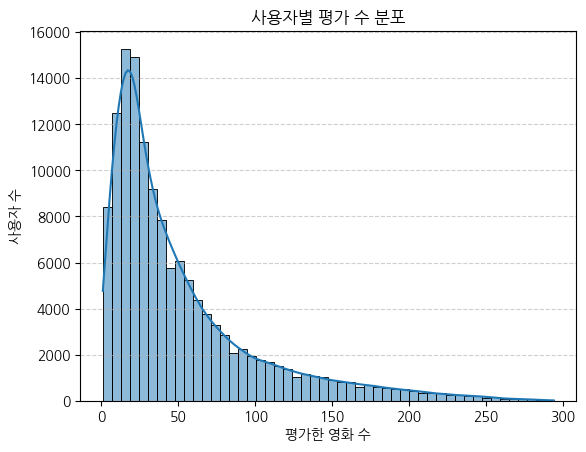

In [ ]:
rated_counts = movie_0_1.notna().sum(axis=1)

# 분포 확인
sns.histplot(rated_counts, bins=50, kde=True)
plt.xlabel("평가한 영화 수")
plt.ylabel("사용자 수")
plt.title("사용자별 평가 수 분포")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [ ]:
cutoff = rated_counts.quantile(0.25) # cutoff = 18개
movie_fil_df = movie_0_1[rated_counts >=cutoff]
movie_fil_df

,1,2,6,10,11,16,17,19,21,25,...,7313,7762,7954,8279,9931,10159,10876,11351,12514,15509
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,3.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.0,NaN,4.5,4.0,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,3.0,4.0,NaN,NaN,NaN,3.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,3.0,NaN,NaN,5.0,NaN,3.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138486,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.5,4.5,4.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN
138488,3.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
138490,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
total_elements = movie_fil_df.shape[0] * movie_fil_df.shape[1]
non_missing = movie_fil_df.notna().sum().sum()
sparsity = 1 - (non_missing/total_elements)
print(sparsity)

0.7775849970250646


In [ ]:
movie_ids = movie_fil_df.columns.astype(int)
genre_df = movie_genre_df[movie_genre_df['movie_id'].isin(movie_ids)].copy()
genre_df = genre_df.drop_duplicates(subset = 'movie_id')
genre_df

,title,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,...,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,movie_id
0,Toy Story (1995),0,0,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,Jumanji (1995),0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
5,Heat (1995),0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,6
9,GoldenEye (1995),0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,10
10,"American President, The (1995)",0,0,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10160,Batman Begins (2005),0,1,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,10159
10876,V for Vendetta (2006),0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,1,1,0,0,10876
11351,"Departed, The (2006)",0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,1,0,0,11351
12514,"Dark Knight, The (2008)",0,1,0,0,0,0,1,0,1,...,0,1,0,0,0,0,0,0,0,12514


# **EDA**

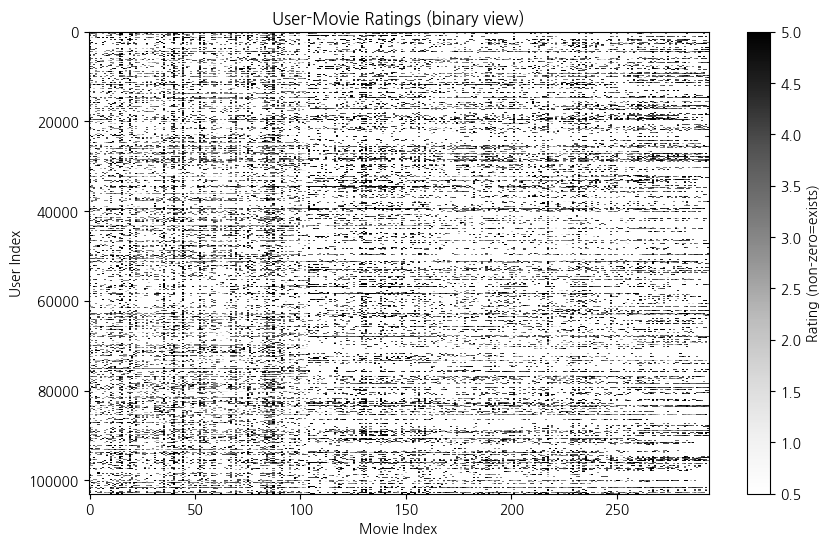

In [ ]:
plt.figure(figsize=(10, 6))
plt.imshow(movie_fil_df, aspect='auto', cmap='Greys', interpolation='none')
plt.title("User-Movie Ratings (binary view)")
plt.xlabel("Movie Index")
plt.ylabel("User Index")
plt.colorbar(label="Rating (non-zero=exists)")
plt.show()

장르 분석

In [ ]:
# 영화별 장르 수
genre_columns = ['(no genres listed)', 'Action', 'Adventure',
       'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama',
       'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery',
       'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
genre_t_df = genre_df.loc[:, ['title']+ genre_columns]
genre_t_df.drop_duplicates(inplace=True)
genre_df = genre_t_df.iloc[:, 1:]
for genre in genre_df.columns:
    count = (genre_df[genre] == 1).sum()
    print(f"{genre}: {count}")

(no genres listed): 0
Action: 105
Adventure: 82
Animation: 18
Children: 27
Comedy: 112
Crime: 62
Documentary: 0
Drama: 111
Fantasy: 39
Film-Noir: 3
Horror: 12
IMAX: 10
Musical: 14
Mystery: 24
Romance: 57
Sci-Fi: 60
Thriller: 89
War: 13
Western: 9


<ipython-input-26-1b8fbe34a8ad>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='pastel')


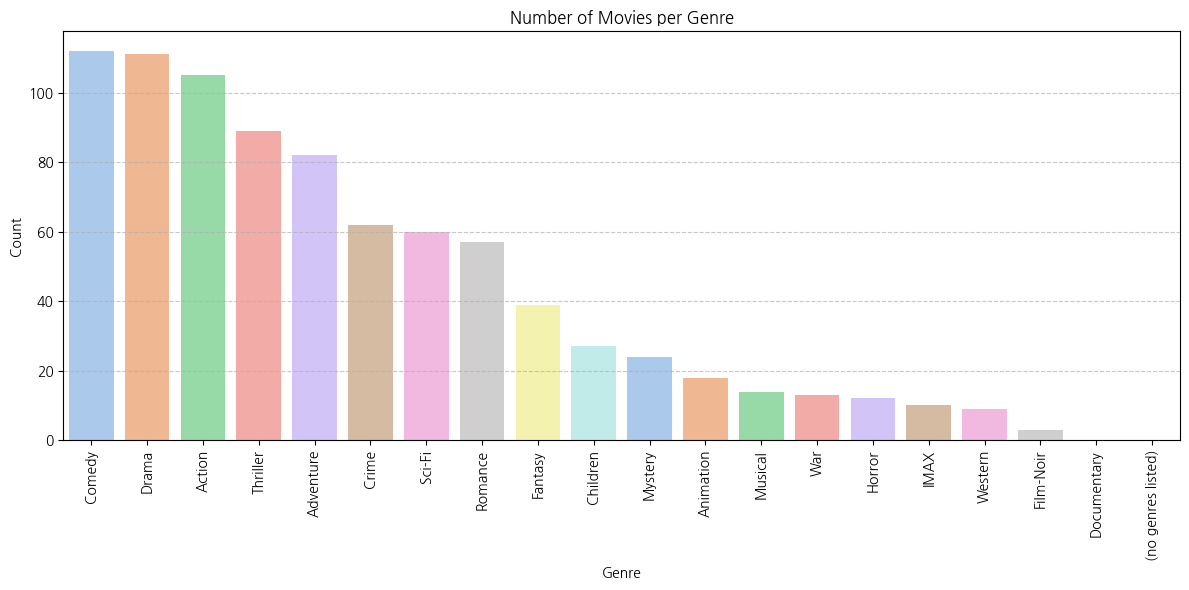

In [ ]:
genre_counts = (genre_df == 1).sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='pastel')

plt.title('Number of Movies per Genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **예측**

**1. user기반** CF

In [ ]:
sample_users = movie_fil_df.index.to_series().sample(n=10000, random_state=42)
movie_small = movie_fil_df.loc[sample_users]

# 1. long-form 데이터로 변환 (userId, movieId, rating)
df_long = movie_small.stack().reset_index()
df_long.columns = ['userId', 'movie_id', 'rating']

# 2. Surprise용 Reader 설정
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(df_long, reader)

# 3. 학습/테스트 분리
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)


# 4. KNN 모델 정의 (user-based)
sim_options = {
    'name': 'cosine',       # 유사도 지표: cosine / msd / pearson
    'user_based': True      # True = user-user CF, False = item-item CF
}

model_user = KNNBasic(sim_options=sim_options)
model_user.fit(trainset)

# 5. 예측
predictions = model_user.test(testset)

# 6. 평가
print("✅ RMSE:", accuracy.rmse(predictions))
print("✅ MAE:", accuracy.mae(predictions))


Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 0.9280
✅ RMSE: 0.9279810189841995
MAE:  0.7118
✅ MAE: 0.7118380773173056


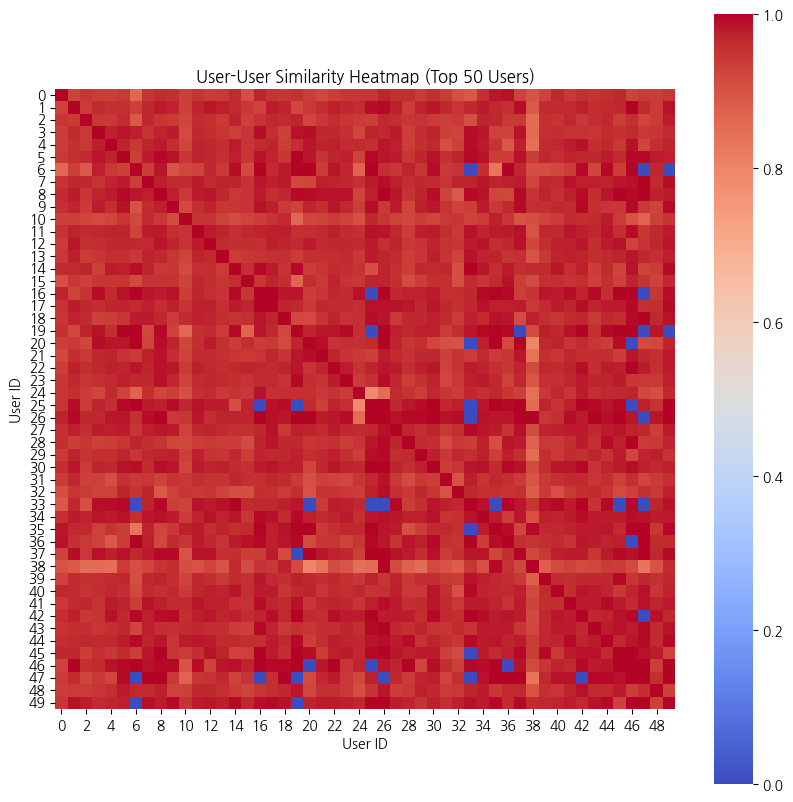

In [ ]:
# 유사도 행렬 추출 (내부 ID 기준)
similarity_matrix = model_user.sim

# 유저 수
n_users = trainset.n_users

# 유사도 행렬 자르기 (상위 50명만 시각화)
subset_size = min(50, n_users)
sim_subset = similarity_matrix[:subset_size, :subset_size]

# 히트맵 시각화
plt.figure(figsize=(10, 10))
sns.heatmap(sim_subset, cmap='coolwarm', square=True)
plt.title("User-User Similarity Heatmap (Top 50 Users)")
plt.xlabel("User ID")
plt.ylabel("User ID")
plt.show()

2. item(영화) 기반 CF

In [ ]:
# 1. long-form 데이터로 변환 (userId, movieId, rating)
df_long = movie_fil_df.stack().reset_index()
df_long.columns = ['userId', 'movie_id', 'rating']

# 2. Surprise용 Reader 설정
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(df_long, reader)

# 3. 학습/테스트 분리
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# 4. KNN 모델 정의 (item-based)
sim_options = {
    'name': 'cosine',       # 유사도 지표: cosine / msd / pearson
    'user_based': False      # True = user-user CF, False = item-item CF
}

model_item = KNNBasic(sim_options=sim_options)
model_item.fit(trainset)

# 5. 예측
predictions = model_item.test(testset)

# 6. 평가
print("✅ RMSE:", accuracy.rmse(predictions))
print("✅ MAE:", accuracy.mae(predictions))

Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 0.8956
✅ RMSE: 0.8956301869491884
MAE:  0.6841
✅ MAE: 0.6840668392810852


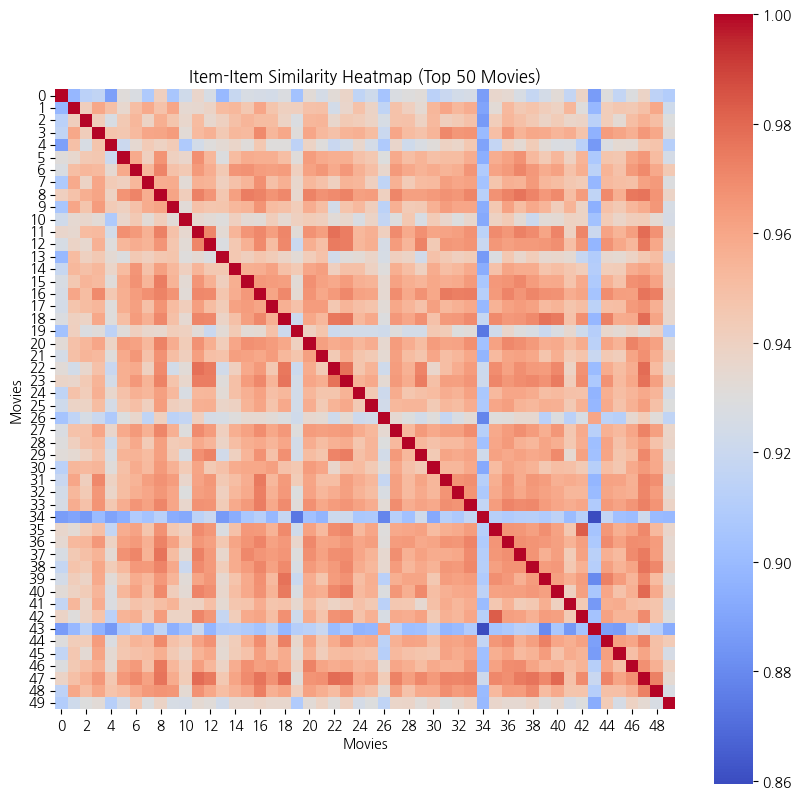

In [ ]:
# 유사도 행렬 추출 (item-item 기반)
similarity_matrix = model_item.sim

# 영화 수
n_movies = trainset.n_items

# 상위 100개 영화의 유사도만 시각화
subset_size = min(50, n_movies)
sim_subset = similarity_matrix[:subset_size, :subset_size]

# 히트맵 시각화
plt.figure(figsize=(10, 10))
sns.heatmap(sim_subset, cmap='coolwarm', square=True)
plt.title("Item-Item Similarity Heatmap (Top 50 Movies)")
plt.xlabel("Movies")
plt.ylabel("Movies")
plt.show()


**3. SVD**

In [ ]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import cross_validate

# 1. long-form 데이터로 변환
df_long = movie_fil_df.stack().reset_index()
df_long.columns = ['userId', 'movie_id', 'rating']

# 2. Surprise용 Reader 설정
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(df_long, reader)

# 3. SVD 모델 정의
model = SVD(n_factors=50, random_state=42, biased=True)

# 4. KFold 교차 검증 수행
results = cross_validate(model, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)


In [ ]:
# 1. long-form 데이터로 변환 (userId, movieId, rating)
df_long = movie_fil_df.stack().reset_index()
df_long.columns = ['userId', 'movie_id', 'rating']

# 2. Surprise용 Reader 설정
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(df_long, reader)

# 3. 학습/테스트 분리
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# 4. SVD 모델 학습
model = SVD(n_factors = 50, random_state=42, biased=True)
model.fit(trainset)

# 5. 예측
predictions = model.test(testset)

# 6. 평가 지표 출력
print("✅ RMSE:", accuracy.rmse(predictions))
print("✅ MAE:", accuracy.mae(predictions))

RMSE: 0.7848
✅ RMSE: 0.7847697099827131
MAE:  0.5975
✅ MAE: 0.5974535208005244


In [ ]:
# 사용자와 아이템 잠재 요인 행렬 접근
user_factors = model.pu  # (n_users x n_factors)
item_factors = model.qi  # (n_items x n_factors)

In [ ]:
# movie_fil_df의 NaN을 예측값으로 채운 버전 생성
predicted_matrix = movie_fil_df.copy()

for user_id in movie_fil_df.index:
    for movie_id in movie_fil_df.columns:
        if pd.isna(movie_fil_df.loc[user_id, movie_id]):
            pred = model.predict(uid=user_id, iid=movie_id).est
            predicted_matrix.loc[user_id, movie_id] = pred

In [ ]:
predicted_matrix.to_csv('/content/drive/MyDrive/데마/data/predicted_matrix.csv')

# **추천**

In [4]:
predicted_matrix = pd.read_csv('/content/drive/MyDrive/데마/data/predicted_matrix.csv', index_col='userId')
predicted_matrix

,1,2,6,10,11,16,17,19,21,25,...,7313,7762,7954,8279,9931,10159,10876,11351,12514,15509
userId,,,,,,,,,,,,,,,,,,,,,
1,4.090058,3.500000,3.629151,3.561123,3.632231,3.347582,3.717839,2.789685,3.368721,3.384772,...,4.000000,3.830471,4.500000,4.000000,3.484714,4.146307,3.923502,3.888461,4.275784,4.208690
2,4.537424,4.098381,4.112077,4.228001,4.061128,3.976969,4.208632,3.336479,4.061561,3.690980,...,4.056233,4.068137,4.249758,4.355660,3.936129,4.484724,4.307249,4.262780,4.617914,4.496060
3,4.000000,4.112523,4.386364,4.091881,4.068641,4.468664,4.218778,3.434170,4.136662,4.524801,...,4.911220,4.329411,4.090908,4.403280,4.866630,4.555484,4.699208,4.737351,4.764818,4.821249
4,4.073374,3.772102,3.000000,4.000000,3.918836,3.642994,4.101422,3.000000,3.509052,3.532472,...,3.994069,3.920705,3.701454,3.953086,4.015791,4.106141,4.090743,4.165586,4.240225,4.328146
5,4.641962,3.000000,4.239399,4.204139,5.000000,3.844681,3.000000,2.666904,3.937651,3.705863,...,3.670884,4.100361,4.151056,4.380811,3.764515,4.457672,4.425522,4.387952,4.575064,4.668806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138486,5.000000,4.217977,3.208665,3.610221,3.798964,3.486792,3.336003,3.985597,2.999242,2.896008,...,4.500000,4.500000,4.000000,4.000000,3.059155,3.392335,3.289068,3.473905,3.571685,3.536534
138488,3.000000,3.000000,3.641788,3.311250,2.918120,3.499683,3.349411,2.730643,3.338733,3.615319,...,3.671259,3.135343,3.281335,3.506460,3.560431,3.853802,3.985308,3.818273,4.145209,4.107315
138490,3.969634,3.424765,3.602346,3.342992,3.560361,3.504106,4.000000,2.612935,3.000000,3.800097,...,3.680410,3.741333,3.289102,3.667464,3.471102,3.639549,3.841772,3.853852,4.042922,3.985607


In [ ]:
# PCA(차원축소)
X = predicted_matrix
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state = 42)
X_pca = pca.fit_transform(X_scaled)

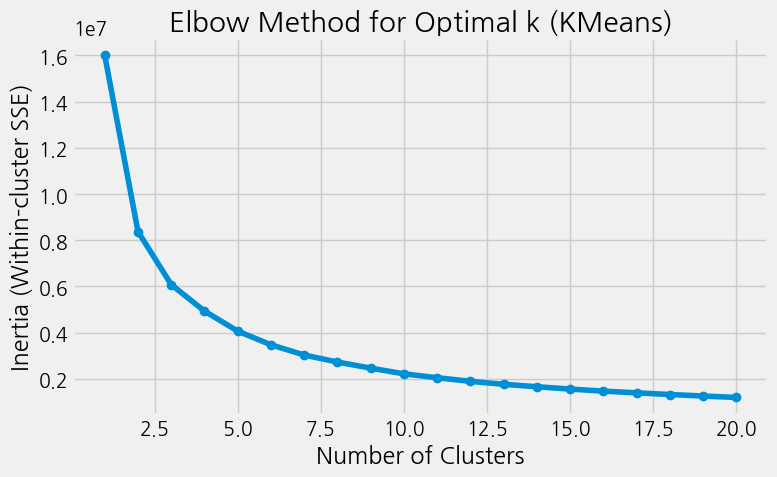

In [ ]:
costs = []
scores = []

K = range(1, 21)

for k in K:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_pca)

    # Inertia = 군집 내 거리합
    costs.append(km.inertia_)

# Elbow plot
plt.figure(figsize=(8, 5))
plt.plot(K, costs, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (Within-cluster SSE)')
plt.title('Elbow Method for Optimal k (KMeans)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
s_results = []
for k in range(5, 11):
  km = KMeans(n_clusters=k, random_state=42)
  cluster_labels = km.fit_predict(X_pca)
  sil_score = silhouette_score(X_pca, cluster_labels)
  s_results.append([k, sil_score])
  print(f"✅ Silhouette Score (k = {k}): {sil_score:.4f}")

pd.DataFrame(s_results, columns=["k", "silhouette_score"])

✅ Silhouette Score (k = 5): 0.3101
✅ Silhouette Score (k = 6): 0.3228
✅ Silhouette Score (k = 7): 0.3213
✅ Silhouette Score (k = 8): 0.3100
✅ Silhouette Score (k = 9): 0.3102
✅ Silhouette Score (k = 10): 0.3238


,k,silhouette_score
0,5,0.310128
1,6,0.322834
2,7,0.321345
3,8,0.309963
4,9,0.310223
5,10,0.323810


In [ ]:
# elbow로 찾은 최적 k 평가 및 label 추가

n_clusters = 10

km = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = km.fit_predict(X_pca)

# X_pca에 cluster 붙이기
X_pca_cluster = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
X_pca_cluster['cluster'] = cluster_labels

# Silhouette Score
sil_score = silhouette_score(X_pca, cluster_labels)
print(f"✅ Silhouette Score: {sil_score:.4f}")

✅ Silhouette Score: 0.3238


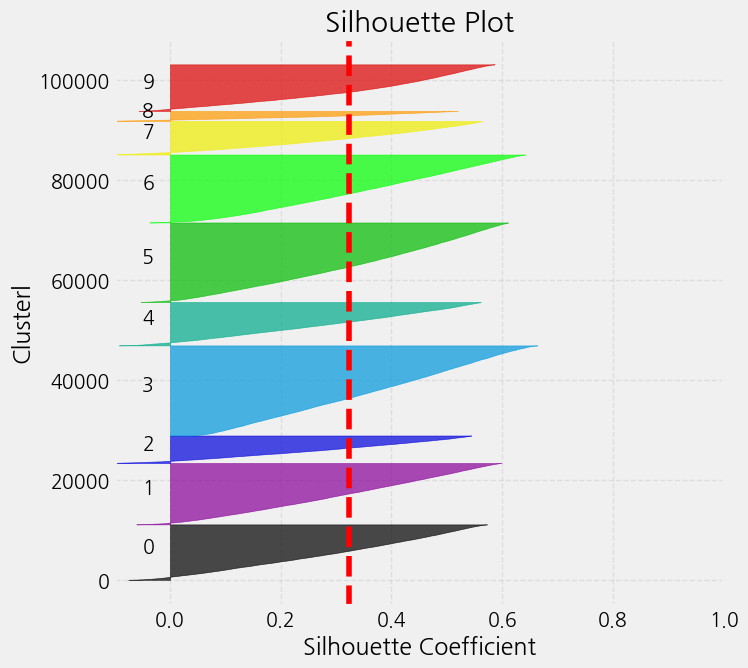

In [ ]:
# silhouette plot
sample_silhouette_values = silhouette_samples(X_pca, cluster_labels)

fig, ax = plt.subplots(figsize=(7, 7))

y_lower = 10
for i in range(n_clusters):
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / n_clusters)
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )
    # 군집 번호
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=sil_score, color="red", linestyle="--")
ax.set_xlim([-0.1, 1])
ax.set_title('Silhouette Plot')
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Clusterl")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


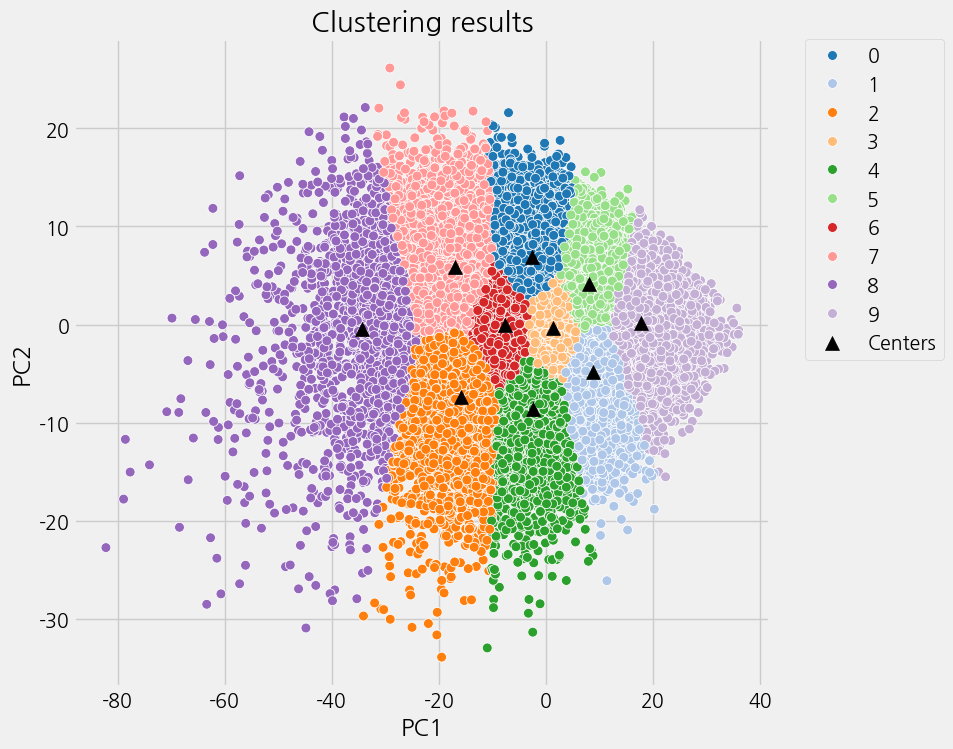

In [ ]:
plt.style.use("fivethirtyeight")
plt.figure(figsize=(8, 8))

# scatterplot 생성
scat = sns.scatterplot(
    data = X_pca_cluster,
    x= "PC1",
    y= "PC2",
    s=50,
    hue= "cluster",
    palette="tab20"
)

# 클러스터 중심점 표시
predicted_centers = km.cluster_centers_
plt.scatter(predicted_centers[:, 0], predicted_centers[:, 1], c='black', marker='^', s=100, label='Centers')

# 그래프 타이틀 및 범주 설정
scat.set_title("Clustering results")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)

plt.show()

**pca 분석**

In [5]:
# PCA(차원축소)
X = predicted_matrix
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state = 42)
X_pca = pca.fit_transform(X_scaled)

# elbow로 찾은 최적 k 평가 및 label 추가
n_clusters = 10

km = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = km.fit_predict(X_pca)

# X_pca에 cluster 붙이기
X_pca_cluster = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
X_pca_cluster['cluster'] = cluster_labels

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)


[0.41717782 0.11105811]


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)


[0.41717782 0.11105811 0.04278234 0.02275444 0.01738849 0.01475381
 0.01104558 0.00763315 0.00630604 0.00580107]


In [11]:
components = pd.DataFrame(pca.components_, columns=X.columns, index=['PC1', 'PC2'])
componentst = components.T
componentst['PC1_abs'] = componentst['PC1'].abs()
componentst['PC2_abs'] = componentst['PC2'].abs()
top_PC1 = componentst.sort_values(by='PC1_abs', ascending=False).head(10)
top_PC2 = componentst.sort_values(by='PC2_abs', ascending=False).head(10)

In [12]:
print(top_PC1)
print(top_PC2)

            PC1       PC2   PC1_abs   PC2_abs
2111   0.074025 -0.001388  0.074025  0.001388
5891   0.073567 -0.016359  0.073567  0.016359
471    0.072793 -0.020003  0.072793  0.020003
2184   0.071852 -0.056428  0.071852  0.056428
15509  0.071839 -0.004744  0.071839  0.004744
1208   0.071087  0.023691  0.071087  0.023691
1917   0.070594 -0.057269  0.070594  0.057269
6235   0.070348 -0.039114  0.070348  0.039114
10159  0.070278 -0.011956  0.070278  0.011956
5322   0.070172 -0.034345  0.070172  0.034345
           PC1       PC2   PC1_abs   PC2_abs
1181  0.032190  0.125497  0.032190  0.125497
110   0.039123  0.122746  0.039123  0.122746
1175  0.037585  0.121695  0.037585  0.121695
233   0.038763  0.121477  0.038763  0.121477
1204  0.040802  0.118412  0.040802  0.118412
738   0.041187  0.115494  0.041187  0.115494
1183  0.041147  0.115176  0.041147  0.115176
6602  0.039733  0.113357  0.039733  0.113357
2912  0.038341  0.112943  0.038341  0.112943
25    0.036957  0.112932  0.036957  0.112932

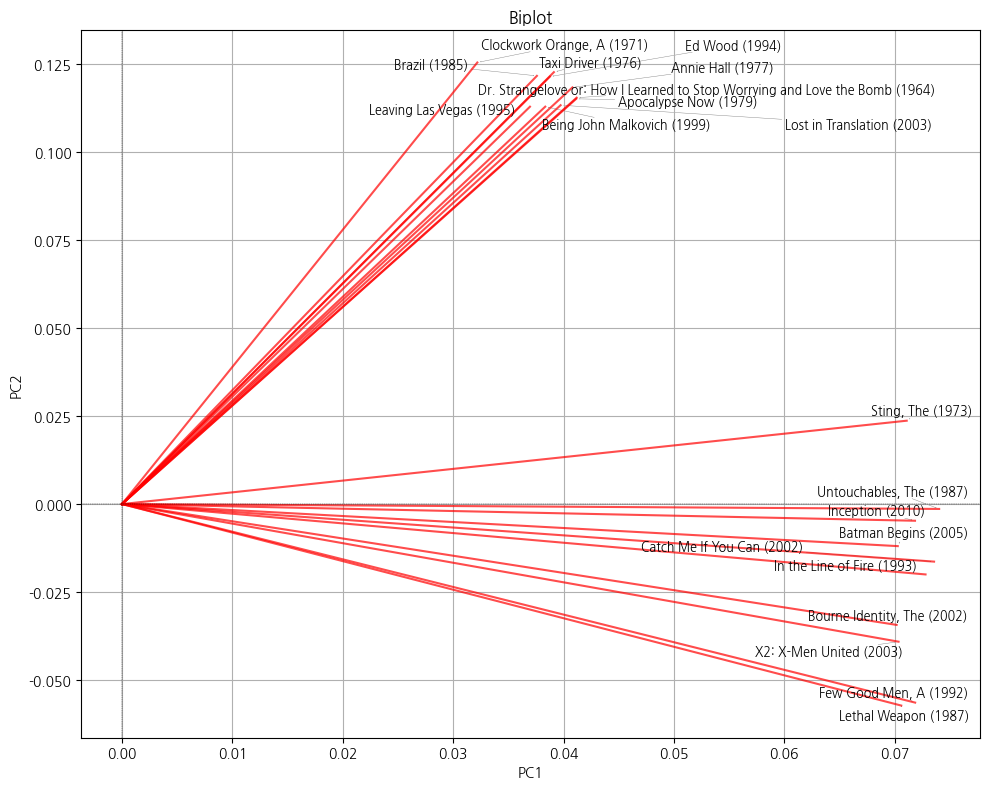

In [96]:
from adjustText import adjust_text
# movie_id → title 매핑
movie_genre_df['movie_id'] = movie_genre_df['movie_id'].astype(str)
title_map = movie_genre_df.drop_duplicates(subset='movie_id').set_index('movie_id')['title']

# components.columns도 title로 바꾸기
components_named = components.copy()
components_named.columns = components_named.columns.astype(str).map(title_map)

texts = []

plt.figure(figsize=(10, 8))

for var in top_variables.index:
    if var in components_named.columns:
        x = components_named.loc['PC1', var]
        y = components_named.loc['PC2', var]
        # 직선 (0,0) → (x,y)
        plt.plot([0, x], [0, y], color='red', alpha=0.7, linewidth=1.5)
        texts.append(plt.text(x, y, var, fontsize=9))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='grey', lw=0.3))

plt.axhline(0, color='black', linestyle='--', linewidth=0.3)
plt.axvline(0, color='black', linestyle='--', linewidth=0.3)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Biplot')
plt.grid(True)
plt.tight_layout()
plt.show()


In [15]:
# PC1, PC2를 구성하는 변수들의 계수 (loading)
components = pd.DataFrame(pca.components_, columns=X.columns, index=['PC1', 'PC2'])
print(components.T.sort_values(by='PC1', ascending=False).head(10))  # PC1에 가장 영향을 많이 준 변수들
print(components.T.sort_values(by='PC2', ascending=False).head(10))

            PC1       PC2
2111   0.074025 -0.001388
5891   0.073567 -0.016359
471    0.072793 -0.020003
2184   0.071852 -0.056428
15509  0.071839 -0.004744
1208   0.071087  0.023691
1917   0.070594 -0.057269
6235   0.070348 -0.039114
10159  0.070278 -0.011956
5322   0.070172 -0.034345
           PC1       PC2
1181  0.032190  0.125497
110   0.039123  0.122746
1175  0.037585  0.121695
233   0.038763  0.121477
1204  0.040802  0.118412
738   0.041187  0.115494
1183  0.041147  0.115176
6602  0.039733  0.113357
2912  0.038341  0.112943
25    0.036957  0.112932


In [ ]:
# 장르 컬럼만 선택
genre_columns = movie_genre_df.columns.difference(['title', 'movie_id'])

# 장르 추출 함수
def extract_genres(row):
    return genre_columns[row[genre_columns] == 1].tolist()

In [ ]:
# PC1
target_users_1 = [2111, 5891, 471, 2184, 15509, 1208, 1917, 6235, 10159, 5322]
movie_genre_1 = movie_genre_df[movie_genre_df['movie_id'].isin(target_users_1)].copy()

# 새 컬럼 생성
movie_genre_1['genres'] = movie_genre_1.apply(extract_genres, axis=1)
movie_genre_1 = movie_genre_1.set_index('movie_id').loc[target_users_1].reset_index()

# 결과 보기
movie_genre_1[['movie_id', 'title', 'genres']]

,movie_id,title,genres
0,2111,"Untouchables, The (1987)","[Action, Crime, Drama]"
1,5891,Catch Me If You Can (2002),"[Crime, Drama]"
2,471,In the Line of Fire (1993),"[Action, Thriller]"
3,2184,"Few Good Men, A (1992)","[Crime, Drama, Thriller]"
4,15509,Inception (2010),"[Action, Crime, Drama, IMAX, Mystery, Sci-Fi, Thriller]"
5,1208,"Sting, The (1973)","[Comedy, Crime]"
6,1917,Lethal Weapon (1987),"[Action, Comedy, Crime, Drama]"
7,6235,X2: X-Men United (2003),"[Action, Adventure, Sci-Fi, Thriller]"
8,10159,Batman Begins (2005),"[Action, Crime, IMAX]"
9,5322,"Bourne Identity, The (2002)","[Action, Mystery, Thriller]"


In [ ]:
genre_1_counts = movie_genre_1.explode('genres')['genres'].value_counts()
genre_1_counts

,count
genres,
Action,7
Crime,7
Drama,5
Thriller,5
IMAX,2
Mystery,2
Sci-Fi,2
Comedy,2
Adventure,1


In [ ]:
# PC2
target_users_2 = [1181, 110, 1175, 233, 1204, 738, 1183, 6602, 2912, 25]
movie_genre_2 = movie_genre_df[movie_genre_df['movie_id'].isin(target_users_2)].copy()

# 새 컬럼 생성
movie_genre_2['genres'] = movie_genre_2.apply(extract_genres, axis=1)
movie_genre_2 = movie_genre_2.set_index('movie_id').loc[target_users_2].reset_index()

# 결과 보기
movie_genre_2[['movie_id', 'title', 'genres']]

,movie_id,title,genres
0,1181,"Clockwork Orange, A (1971)","[Crime, Drama, Sci-Fi, Thriller]"
1,110,Taxi Driver (1976),"[Crime, Drama, Thriller]"
2,1175,Brazil (1985),"[Fantasy, Sci-Fi]"
3,233,Ed Wood (1994),"[Comedy, Drama]"
4,1204,Annie Hall (1977),"[Comedy, Romance]"
5,738,Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),"[Comedy, War]"
6,1183,Apocalypse Now (1979),"[Action, Drama, War]"
7,6602,Lost in Translation (2003),"[Comedy, Drama, Romance]"
8,2912,Being John Malkovich (1999),"[Comedy, Drama, Fantasy]"
9,25,Leaving Las Vegas (1995),"[Drama, Romance]"


In [ ]:
genre_2_counts = movie_genre_2.explode('genres')['genres'].value_counts()
genre_2_counts

,count
genres,
Drama,7
Comedy,5
Romance,3
Crime,2
Sci-Fi,2
Thriller,2
Fantasy,2
War,2
Action,1


In [ ]:
ge_cols = ['(no genres listed)', 'Action', 'Adventure', 'Animation',
       'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy',
       'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance',
       'Sci-Fi', 'Thriller', 'War', 'Western']
genre_1_counts = movie_genre_1.explode('genres')['genres'].value_counts()
genre_2_counts = movie_genre_2.explode('genres')['genres'].value_counts()
ge_df = pd.DataFrame({'genre' :ge_cols,
                      'PC1': [genre_1_counts.get(g, 0) for g in ge_cols],
                      'PC2': [genre_2_counts.get(g, 0) for g in ge_cols]})
ge_df

,genre,PC1,PC2
0,(no genres listed),0,0
1,Action,7,1
2,Adventure,1,0
3,Animation,0,0
4,Children,0,0
5,Comedy,2,5
6,Crime,7,2
7,Documentary,0,0
8,Drama,5,7
9,Fantasy,0,2


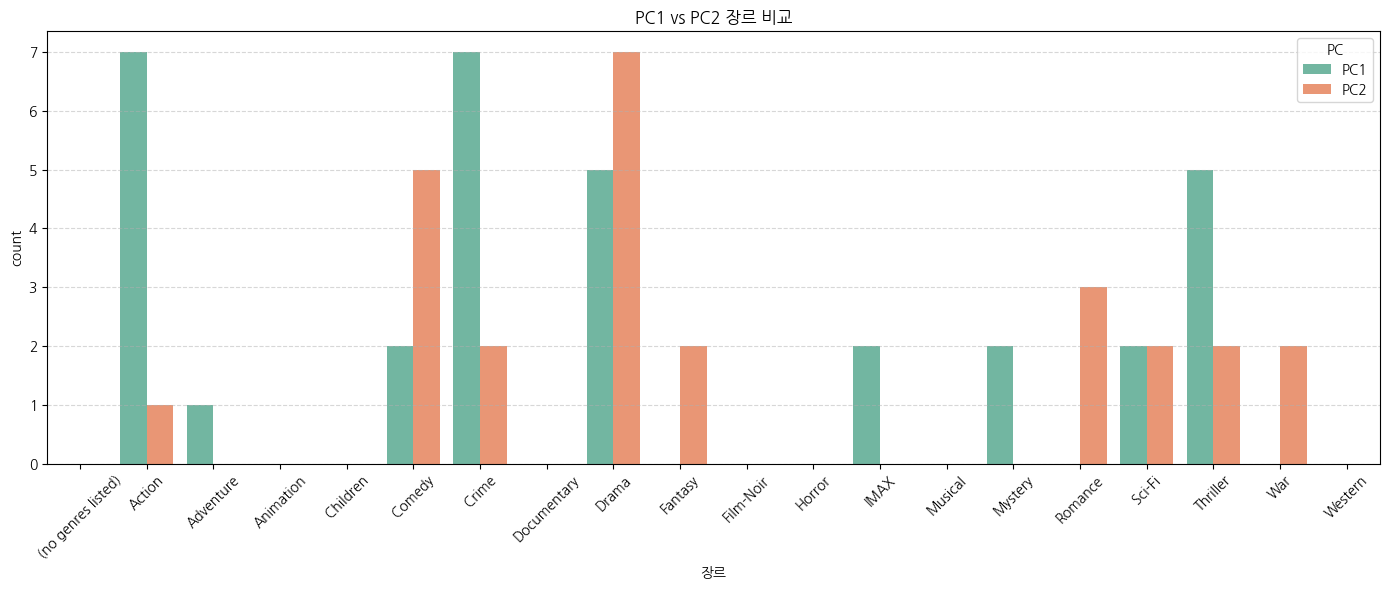

In [ ]:
plt.figure(figsize=(14, 6))
ge_df_long = ge_df.melt(id_vars='genre', var_name='PC', value_name='count')
sns.barplot(x='genre', y='count', hue='PC', data=ge_df_long, palette='Set2')

plt.title("PC1 vs PC2 장르 비교")
plt.xlabel("장르")
plt.ylabel("count")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Cluster 0: 11084 users
Cluster 1: 12260 users
Cluster 2: 5496 users
Cluster 3: 18006 users
Cluster 4: 8671 users
Cluster 5: 15895 users
Cluster 6: 13573 users
Cluster 7: 6706 users
Cluster 8: 1991 users
Cluster 9: 9310 users


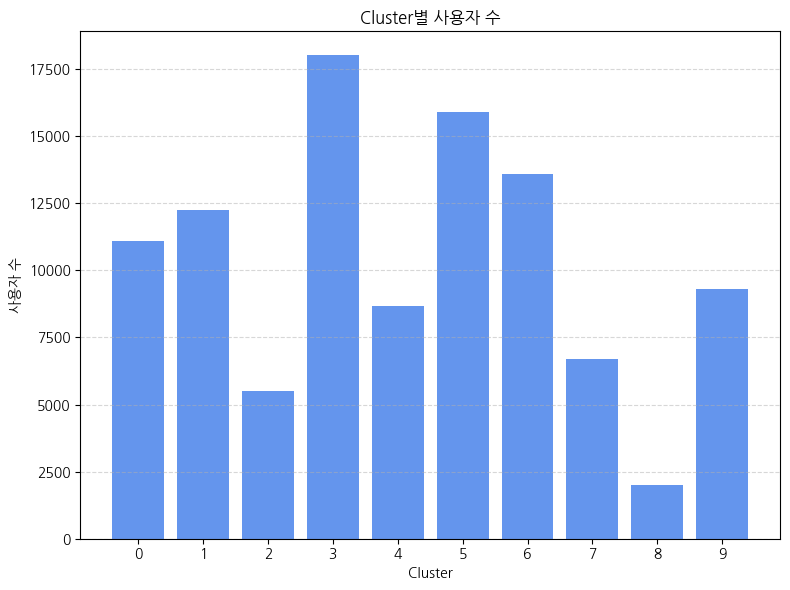

In [ ]:
# 군집별 사용자 수 확인
unique, counts = np.unique(cluster_labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f"Cluster {c}: {n} users")

plt.figure(figsize=(8, 6))
plt.bar(x=unique, height=counts, color = 'cornflowerblue')

plt.xticks(unique)
plt.xlabel('Cluster')
plt.ylabel('사용자 수')
plt.title('Cluster별 사용자 수')
plt.tight_layout()
plt.grid(axis='y', linestyle='--',alpha=0.5)
plt.show()

In [ ]:
# cluster 번호 사용자별로 붙이기
movie_fil_df_clustered = predicted_matrix.copy()
movie_fil_df_clustered['cluster'] = cluster_labels

# 군집별 영화 평균 평점 계산
cluster_avg = movie_fil_df_clustered.groupby('cluster').mean()

<ipython-input-21-53e3753e5751>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cluster_avg_long, x='cluster', y='평점', palette='Set3')


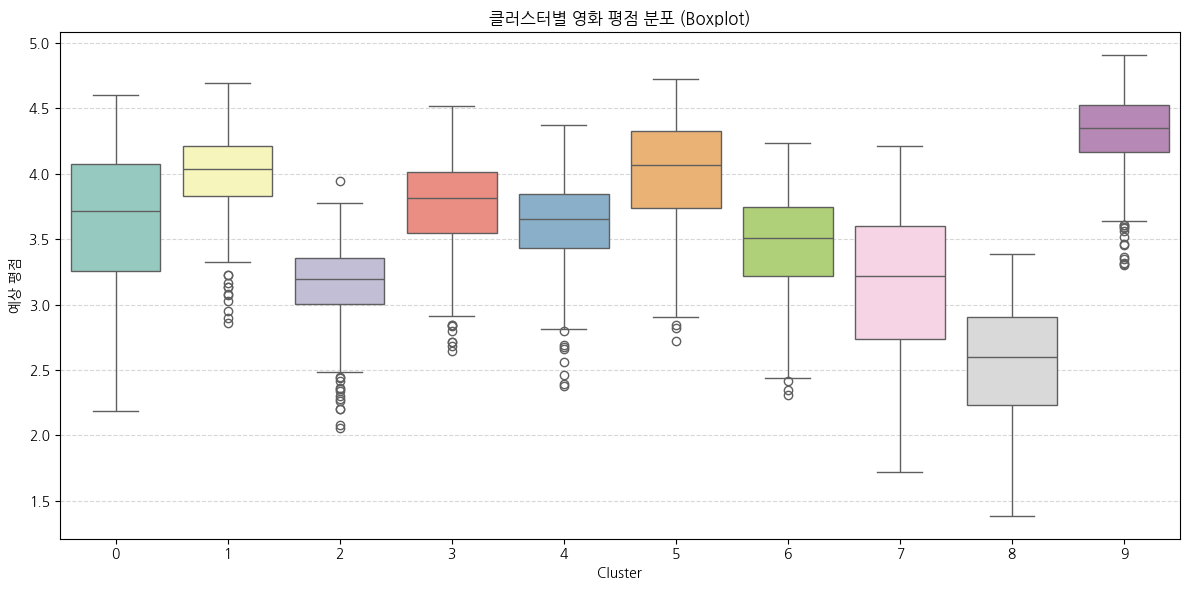

In [ ]:
# 클러스터별 전체 영화 평균 평점에 대한 기술통계
cluster_summary = cluster_avg.T.describe().T[
    ['mean', 'std', 'min', '25%', '50%', '75%', 'max']
]

plt.figure(figsize=(12, 6))

# long-form 으로 변환: cluster × movie_id → long 형태
cluster_avg_long = cluster_avg.reset_index().melt(id_vars='cluster', var_name='movie_id', value_name='평점')

sns.boxplot(data=cluster_avg_long, x='cluster', y='평점', palette='Set3')
plt.title("클러스터별 영화 평점 분포 (Boxplot)")
plt.xlabel("Cluster")
plt.ylabel("예상 평점")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


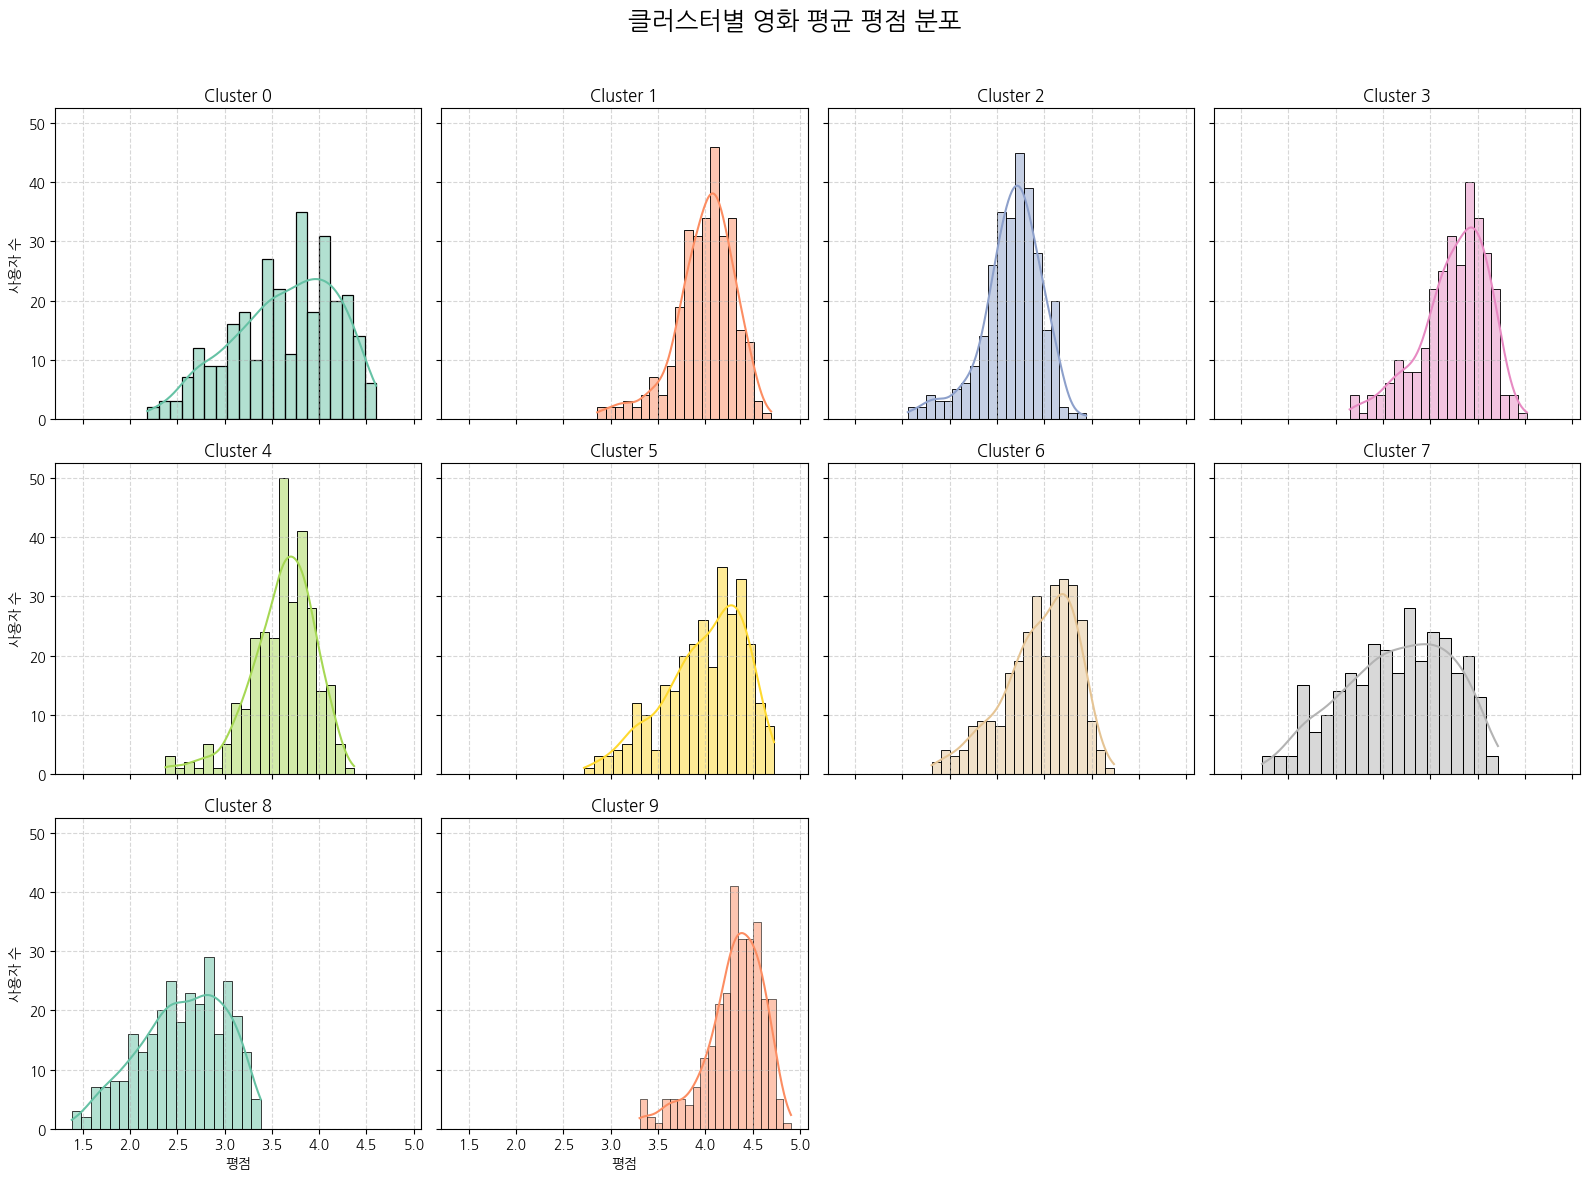

In [ ]:
num_clusters = len(cluster_avg.index)
ncols = 4
nrows = (num_clusters + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, nrows * 4), sharex=True, sharey=True)
axes = axes.flatten()

# 각 클러스터별 히스토그램
for i, cluster_id in enumerate(unique_clusters):
    ax = axes[i]
    sns.histplot(cluster_avg.loc[cluster_id], kde=True, bins=20,
                 ax=ax, color=sns.color_palette("Set2")[i % 8])
    ax.set_title(f"Cluster {cluster_id}")
    ax.set_xlabel("평점")
    ax.set_ylabel("사용자 수")
    ax.grid(True, linestyle='--', alpha=0.5)

# 남는 subplot 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("클러스터별 영화 평균 평점 분포", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

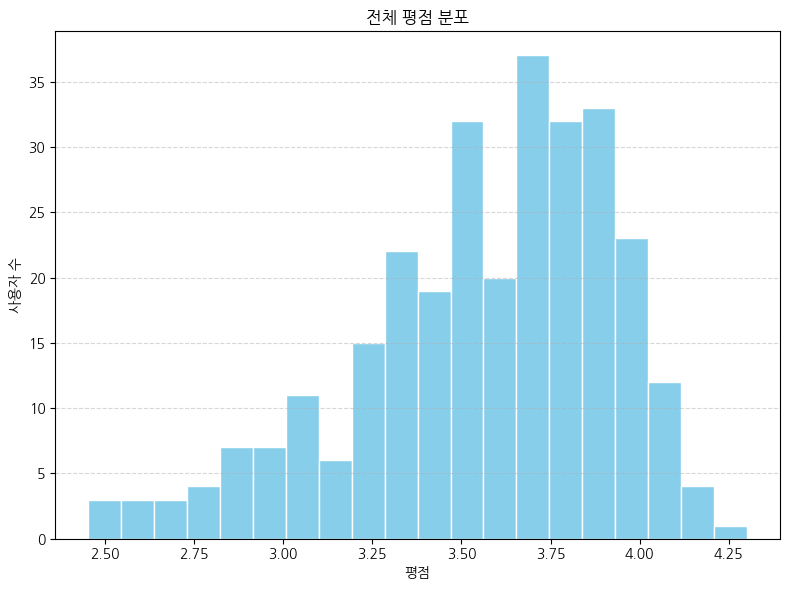

In [ ]:
global_avg = cluster_avg.mean(axis=0)
plt.figure(figsize=(8, 6))
plt.hist(global_avg, bins=20, color='skyblue', edgecolor='white')
plt.title('전체 평점 분포')
plt.xlabel('평점')
plt.ylabel('사용자 수')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# cluster 번호 사용자별로 붙이기
movie_fil_df_clustered = predicted_matrix.copy()
movie_fil_df_clustered['cluster'] = cluster_labels

# 군집별 영화 평균 평점 계산
cluster_avg = movie_fil_df_clustered.groupby('cluster').mean()
# 영화 제목 매핑 딕셔너리 만들기
movie_id_to_title = dict(zip(genre_df['movie_id'], genre_df['title']))

# 결과 저장용 리스트
results = []

# 추천/비추천 영화 추출
top_n = 3
for cluster_id in range(n_clusters):
    # 추천 영화
    p_movies = cluster_avg.loc[cluster_id].sort_values(ascending=False).head(top_n)
    for movie_id, score in p_movies.items():
        title = movie_id_to_title.get(int(movie_id), f"(ID {movie_id})")
        results.append({
            "Cluster": cluster_id,
            "구분": "❤️ 추천",
            "영화 제목": title,
            "예상 평점": round(score, 2)
        })

    # 비추천 영화
    m_movies = cluster_avg.loc[cluster_id].sort_values(ascending=True).head(top_n)
    for movie_id, score in m_movies.items():
        title = movie_id_to_title.get(int(movie_id), f"(ID {movie_id})")
        results.append({
            "Cluster": cluster_id,
            "구분": "🖤 비추천",
            "영화 제목": title,
            "예상 평점": round(score, 2)
        })

# DataFrame으로 정리
result_df = pd.DataFrame(results)
result_df = result_df.sort_values(by=["Cluster", "구분"], ascending=[True, False]).reset_index(drop=True)

# 출력
from IPython.display import display
display(result_df)


,Cluster,구분,영화 제목,예상 평점
0,0,🖤 비추천,Judge Dredd (1995),2.18
1,0,🖤 비추천,Congo (1995),2.27
2,0,🖤 비추천,Armageddon (1998),2.32
3,0,❤️ 추천,Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),4.60
4,0,❤️ 추천,"Godfather, The (1972)",4.59
5,0,❤️ 추천,Pulp Fiction (1994),4.58
6,1,🖤 비추천,"Blair Witch Project, The (1999)",2.86
7,1,🖤 비추천,"Cable Guy, The (1996)",2.90
8,1,🖤 비추천,Natural Born Killers (1994),2.95
9,1,❤️ 추천,"Shawshank Redemption, The (1994)",4.70


🔍 축 해석
x축 (예상 평점):
해당 영화가 클러스터 사용자들에게 얼마나 높게 예측됐는지
- 오른쪽으로 갈수록 클러스터 유저들이 높게 평가할 것이라는 예측

y축 (특이성 점수):
전체 평균 대비 얼마나 특화되어 있는지
- 위로 갈수록 이 클러스터에서 유독 선호하거나 비선호하는 영화

📌 주요 해석 포인트

✅ 1. 오른쪽 위 (예상 평점 ↑, 특이성 ↑)
- 클러스터 유저들이 매우 좋아하고,
- 다른 클러스터와 비교해 유독 이 클러스터에서만 선호하는 영화들
✅ 대부분 💡 특화 추천

✅ 2. 오른쪽 아래 (예상 평점 ↑, 특이성 ↓)
- 예상 평점은 높지만, 다른 클러스터에서도 비슷하게 높을 가능성
- 특이성이 낮아져 💡보다는 ❤️로 분류

✅ 3. 왼쪽 위 (예상 평점 ↓, 특이성 ↑)
- 평균적으로 낮은 영화지만, 특정 클러스터에서는 상대적으로 선호
- 이런 영화도 💡 특화 추천이 될 수 있음 (소수 취향 저격)

✅ 4. 왼쪽 아래 (예상 평점 ↓, 특이성 ↓)
- 전체적으로도 인기가 낮고, 이 클러스터에서도 비선호
- 대부분 🖤 비추천

💬 예시적 해석
예: Cluster 5의 파란색 △ (특화 추천)
- 해당 클러스터는 대중과 달리 어떤 영화를 유독 선호함을 의미

예: Cluster 3의 빨간색 ● (비추천)
- 해당 클러스터는 특정 영화를 아주 안 좋아하는 경향

*같은 위치에 몰린 마커는 클러스터 간 경향 중복 시사

In [ ]:
# 클러스터별 평균 평점
cluster_avg = movie_fil_df_clustered.groupby('cluster').mean()

# 전체 평균 및 표준편차 계산 (영화별)
global_avg = cluster_avg.mean(axis=0)
global_std = cluster_avg.std(axis=0)

# movie_id → title 변환 딕셔너리
movie_id_to_title = dict(zip(genre_df['movie_id'], genre_df['title']))

# 결과 저장
results = []

top_n = 3
for cluster_id in range(n_clusters):
    # ✅ 추천 영화
    p_movies = cluster_avg.loc[cluster_id].sort_values(ascending=False).head(top_n)
    for movie_id, score in p_movies.items():
        title = movie_id_to_title.get(int(movie_id), f"(ID {movie_id})")
        delta = score - global_avg.get(movie_id, 0)
        results.append({
            "Cluster": cluster_id,
            "구분": "추천",
            "영화 제목": title,
            "예상 평점": round(score, 2),
            "특이성 점수": round(delta, 2)
        })

    # ✅ 비추천 영화
    m_movies = cluster_avg.loc[cluster_id].sort_values(ascending=True).head(top_n)
    for movie_id, score in m_movies.items():
        title = movie_id_to_title.get(int(movie_id), f"(ID {movie_id})")
        delta = score - global_avg.get(movie_id, 0)
        results.append({
            "Cluster": cluster_id,
            "구분": "비추천",
            "영화 제목": title,
            "예상 평점": round(score, 2),
            "특이성 점수": round(delta, 2)
        })

    # ✅ z-score 기반 특화 추천
    delta = cluster_avg.loc[cluster_id] - global_avg
    z_score = delta / global_std
    top_z = z_score.sort_values(ascending=False).head(top_n)

    for movie_id, z in top_z.items():
        score = cluster_avg.loc[cluster_id, movie_id]
        title = movie_id_to_title.get(int(movie_id), f"(ID {movie_id})")
        results.append({
            "Cluster": cluster_id,
            "구분": "특화 추천",
            "영화 제목": title,
            "예상 평점": round(score, 2),
            "특이성 점수": round(z, 2)
        })

# 결과 DataFrame 정리
result_df = pd.DataFrame(results)
result_df = result_df.sort_values(by=["Cluster", "구분"], ascending=[True, False]).reset_index(drop=True)

# 보기 좋게 출력
from IPython.display import display
display(result_df)


,Cluster,구분,영화 제목,예상 평점,특이성 점수
0,0,특화 추천,"Clockwork Orange, A (1971)",4.40,1.16
1,0,특화 추천,Pulp Fiction (1994),4.58,1.12
2,0,특화 추천,Natural Born Killers (1994),3.62,1.11
3,0,추천,Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),4.60,0.53
4,0,추천,"Godfather, The (1972)",4.59,0.43
...,...,...,...,...,...
85,9,추천,Schindler's List (1993),4.82,0.65
86,9,추천,Life Is Beautiful (La Vita è bella) (1997),4.82,0.67
87,9,비추천,Judge Dredd (1995),3.31,0.85
88,9,비추천,"Cable Guy, The (1996)",3.31,0.76


In [ ]:
result_df.to_csv('/content/drive/MyDrive/데마/data/result_df.csv')

NameError: name 'result_df' is not defined

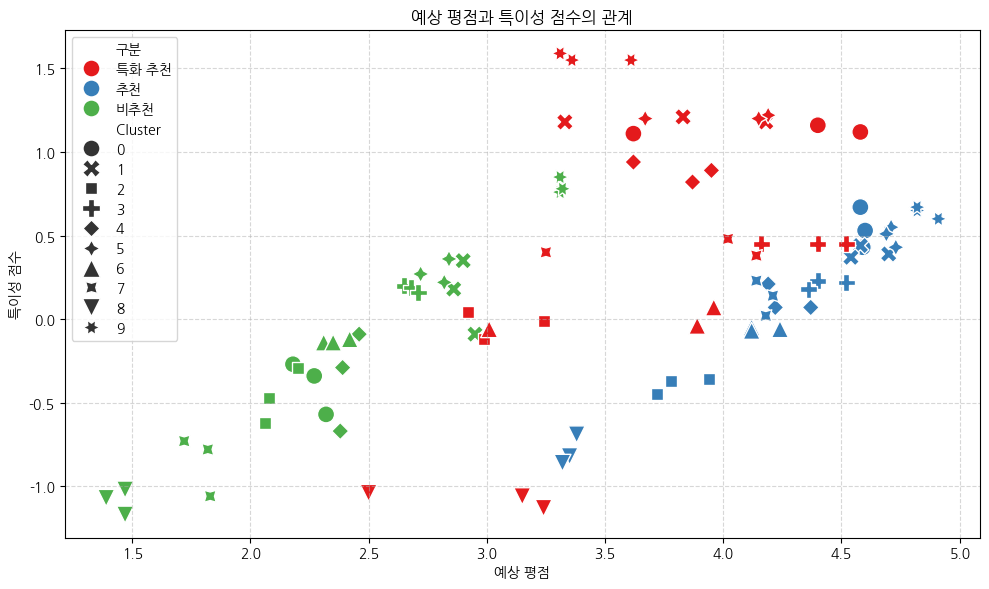

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=result_df, x='예상 평점', y='특이성 점수', hue='구분', style='Cluster', s=150, palette='Set1')
plt.title("예상 평점과 특이성 점수의 관계")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
pip install adjustText

In [ ]:
distinct_df = result_df[result_df['구분'] == '특화 추천'].copy()
distinct_df

,Cluster,구분,영화 제목,예상 평점,특이성 점수
0,0,특화 추천,"Clockwork Orange, A (1971)",4.40,1.16
1,0,특화 추천,Pulp Fiction (1994),4.58,1.12
2,0,특화 추천,Natural Born Killers (1994),3.62,1.11
9,1,특화 추천,Armageddon (1998),3.83,1.21
10,1,특화 추천,Independence Day (a.k.a. ID4) (1996),4.18,1.18
11,1,특화 추천,Congo (1995),3.33,1.18
18,2,특화 추천,Armageddon (1998),2.92,0.04
19,2,특화 추천,Independence Day (a.k.a. ID4) (1996),3.24,-0.01
20,2,특화 추천,Twister (1996),2.99,-0.12
27,3,특화 추천,"Shawshank Redemption, The (1994)",4.52,0.45


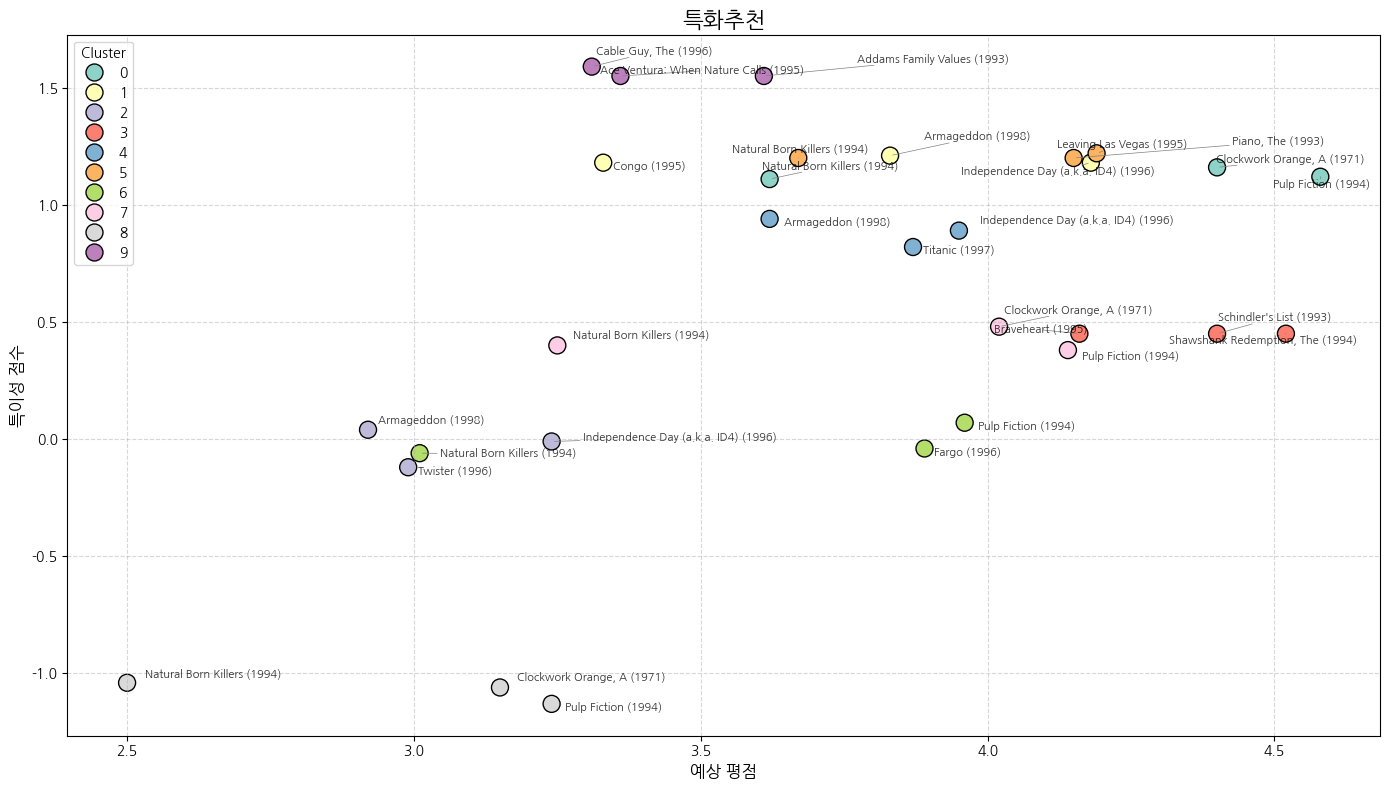

In [ ]:
from adjustText import adjust_text
texts = []
filtered_df = distinct_df.copy()
# 산점도 그리기
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=filtered_df,
    x='예상 평점',
    y='특이성 점수',
    hue='Cluster',
    palette='Set3',
    s=150,
    edgecolor='black'
)

# 텍스트 생성
for _, row in filtered_df.iterrows():
    texts.append(
        plt.text(row['예상 평점'], row['특이성 점수'], row['영화 제목'],
                 fontsize=8, alpha=0.8)
    )

# 텍스트 겹침 조정
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
plt.title("특화추천", fontsize=16)
plt.xlabel("예상 평점", fontsize=12)
plt.ylabel("특이성 점수", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# Step 1: 추천 유형별로 분리
rec_df = result_df[result_df['구분'] == '추천'][['영화 제목', 'Cluster']]
nonrec_df = result_df[result_df['구분'] == '비추천'][['영화 제목', 'Cluster']]
distinct_df = result_df[result_df['구분'] == '특화 추천'][['영화 제목', 'Cluster']]

# Step 2: 클러스터 리스트로 그룹화
rec_grouped = rec_df.groupby('영화 제목')['Cluster'].apply(sorted).reset_index(name='❤️ 추천 클러스터')
nonrec_grouped = nonrec_df.groupby('영화 제목')['Cluster'].apply(sorted).reset_index(name='🖤 비추천 클러스터')
distinct_grouped = distinct_df.groupby('영화 제목')['Cluster'].apply(sorted).reset_index(name='💡 특화 추천 클러스터')

# Step 3: merge
summary_df = pd.merge(rec_grouped, nonrec_grouped, on='영화 제목', how='outer')
summary_df = pd.merge(summary_df, distinct_grouped, on='영화 제목', how='outer')

# Step 4: 결측치는 빈 리스트로 채우기
# 리스트가 아닌 경우 빈 리스트로 바꾸기
# Step 4: 리스트 컬럼만 NaN → 빈 리스트로 변환
for col in ['❤️ 추천 클러스터', '🖤 비추천 클러스터', '💡 특화 추천 클러스터']:
    summary_df[col] = summary_df[col].apply(lambda x: x if isinstance(x, list) else [])

# 결과 보기
from IPython.display import display
display(summary_df)


,영화 제목,❤️ 추천 클러스터,🖤 비추천 클러스터,💡 특화 추천 클러스터
0,Ace Ventura: When Nature Calls (1995),[],"[2, 3, 5, 6, 8]",[9]
1,Addams Family Values (1993),[],[],[9]
2,Armageddon (1998),[],"[0, 7]","[1, 2, 4]"
3,"Blair Witch Project, The (1999)",[],"[1, 2, 4]",[]
4,Braveheart (1995),[],[],[3]
5,"Cable Guy, The (1996)",[],"[1, 2, 3, 4, 9]",[9]
6,"Clockwork Orange, A (1971)",[],[],"[0, 7, 8]"
7,Coneheads (1993),[],"[6, 9]",[]
8,Congo (1995),[],"[0, 5, 7]",[1]
9,Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),"[0, 7, 8]",[],[]


In [ ]:
top_n = 5
cluster_id = 0  # 추천하고 싶은 클러스터 번호

# 전체 평균 평점
global_avg = cluster_avg.mean()

# 해당 클러스터의 평균 - 전체 평균 = 클러스터 특이성 점수
delta_score = cluster_avg.loc[cluster_id] - global_avg

# 내림차순 정렬 → 특히 선호하는 영화
top_distinct_movies = delta_score.sort_values(ascending=False).head(top_n)

# 결과 출력
print(f"🎯 Cluster {cluster_id}에서 특히 좋아할 가능성이 높은 영화 Top {top_n}:")
for movie_id, delta in top_distinct_movies.items():
    title = movie_id_to_title.get(int(movie_id), f"(ID {movie_id})")
    score = cluster_avg.loc[cluster_id, movie_id]
    print(f"  • {title} (예상평점: {score:.2f}, 전체 대비 +{delta:.2f})")

🎯 Cluster 0에서 특히 좋아할 가능성이 높은 영화 Top 5:
  • Pulp Fiction (1994) (예상평점: 4.58, 전체 대비 +0.67)
  • Clockwork Orange, A (1971) (예상평점: 4.40, 전체 대비 +0.65)
  • 2001: A Space Odyssey (1968) (예상평점: 4.30, 전체 대비 +0.58)
  • Natural Born Killers (1994) (예상평점: 3.62, 전체 대비 +0.58)
  • Taxi Driver (1976) (예상평점: 4.41, 전체 대비 +0.57)


군집별 추천영화 시청비율

In [ ]:
cluster_ratio = movie_fil_df.copy()
cluster_ratio['cluster'] = movie_fil_df_clustered['cluster']
cluster_ratio

,1,2,6,10,11,16,17,19,21,25,...,7762,7954,8279,9931,10159,10876,11351,12514,15509,cluster
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,3.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,4.5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,4
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9
4,NaN,NaN,3.0,4.0,NaN,NaN,NaN,3.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
5,NaN,3.0,NaN,NaN,5.0,NaN,3.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138486,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.5,4.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,4
138488,3.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
138490,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6


In [ ]:
result_df = pd.read_csv('/content/drive/MyDrive/데마/data/result_df.csv').drop(columns='Unnamed: 0')
result_df_id = result_df.copy()
result_df_id = result_df_id.merge(genre_df[['movie_id', 'title']], left_on = '영화 제목', right_on='title', how='left').drop(columns='title')
result_df_id

,Cluster,구분,영화 제목,예상 평점,특이성 점수,movie_id
0,0,특화 추천,"Clockwork Orange, A (1971)",4.40,1.16,1181
1,0,특화 추천,Pulp Fiction (1994),4.58,1.12,294
2,0,특화 추천,Natural Born Killers (1994),3.62,1.11,286
3,0,추천,Dr. Strangelove or: How I Learned to Stop Worr...,4.60,0.53,738
4,0,추천,"Godfather, The (1972)",4.59,0.43,844
...,...,...,...,...,...,...
85,9,추천,Schindler's List (1993),4.82,0.65,524
86,9,추천,Life Is Beautiful (La Vita è bella) (1997),4.82,0.67,2240
87,9,비추천,Judge Dredd (1995),3.31,0.85,172
88,9,비추천,"Cable Guy, The (1996)",3.31,0.76,772


In [ ]:
# 모든 컬럼을 문자열로 변환
cluster_ratio.columns = cluster_ratio.columns.astype(str)

# 결과 저장용 리스트
view_ratios = []

# 각 영화에 대해
for _, row in result_df_id.iterrows():
    movie_id = row['movie_id']
    target_cluster = row['Cluster']

    # 클러스터에 속한 유저들만 추출
    cluster_users = cluster_ratio[cluster_ratio['cluster'] == target_cluster]

    # 전체 유저 수
    total_users = len(cluster_users)
    # movie_id도 문자열로 처리
    movie_id = str(row['movie_id'])
    # 시청한 유저 수 (NaN이 아닌 값)
    watched_users = cluster_users[movie_id].notna().sum()

    # 시청 비율 계산
    ratio = watched_users / total_users if total_users > 0 else None

    # 저장
    view_ratios.append(ratio)

# result_df_id에 새로운 컬럼으로 추가
result_df_id['클러스터 시청비율'] = view_ratios
result_df_id

,Cluster,구분,영화 제목,예상 평점,특이성 점수,movie_id,클러스터 시청비율
0,0,특화 추천,"Clockwork Orange, A (1971)",4.40,1.16,1181,0.380549
1,0,특화 추천,Pulp Fiction (1994),4.58,1.12,294,0.744767
2,0,특화 추천,Natural Born Killers (1994),3.62,1.11,286,0.297095
3,0,추천,Dr. Strangelove or: How I Learned to Stop Worr...,4.60,0.53,738,0.368910
4,0,추천,"Godfather, The (1972)",4.59,0.43,844,0.467701
...,...,...,...,...,...,...,...
85,9,추천,Schindler's List (1993),4.82,0.65,524,0.373255
86,9,추천,Life Is Beautiful (La Vita è bella) (1997),4.82,0.67,2240,0.121053
87,9,비추천,Judge Dredd (1995),3.31,0.85,172,0.146187
88,9,비추천,"Cable Guy, The (1996)",3.31,0.76,772,0.093233


In [ ]:
result_df_id[result_df_id['구분']=='추천']

,Cluster,구분,영화 제목,예상 평점,특이성 점수,movie_id,클러스터 시청비율
3,0,추천,Dr. Strangelove or: How I Learned to Stop Worr...,4.60,0.53,738,0.368910
4,0,추천,"Godfather, The (1972)",4.59,0.43,844,0.467701
5,0,추천,Pulp Fiction (1994),4.58,0.67,294,0.744767
12,1,추천,"Shawshank Redemption, The (1994)",4.70,0.39,316,0.490375
13,1,추천,Life Is Beautiful (La Vita è bella) (1997),4.58,0.44,2240,0.102773
14,1,추천,Schindler's List (1993),4.54,0.37,524,0.370718
21,2,추천,"Shawshank Redemption, The (1994)",3.94,-0.36,316,0.555495
22,2,추천,Life Is Beautiful (La Vita è bella) (1997),3.78,-0.37,2240,0.163392
23,2,추천,Schindler's List (1993),3.72,-0.45,524,0.446507
30,3,추천,"Shawshank Redemption, The (1994)",4.52,0.22,316,0.570032


In [ ]:
result_df_id[result_df_id['구분']=='비추천']

,Cluster,구분,영화 제목,예상 평점,특이성 점수,movie_id,클러스터 시청비율
6,0,비추천,Judge Dredd (1995),2.18,-0.27,172,0.143450
7,0,비추천,Congo (1995),2.27,-0.34,159,0.130368
8,0,비추천,Armageddon (1998),2.32,-0.57,1834,0.225460
15,1,비추천,"Blair Witch Project, The (1999)",2.86,0.18,2625,0.113051
16,1,비추천,"Cable Guy, The (1996)",2.90,0.35,772,0.103181
17,1,비추천,Natural Born Killers (1994),2.95,-0.09,286,0.179119
24,2,비추천,"Blair Witch Project, The (1999)",2.06,-0.62,2625,0.187773
25,2,비추천,"Cable Guy, The (1996)",2.08,-0.47,772,0.158479
26,2,비추천,Ace Ventura: When Nature Calls (1995),2.20,-0.29,19,0.253275
33,3,비추천,Judge Dredd (1995),2.65,0.20,172,0.123015


In [ ]:
result_df_id[result_df_id['구분']=='특화 추천']

,Cluster,구분,영화 제목,예상 평점,특이성 점수,movie_id,클러스터 시청비율
0,0,특화 추천,"Clockwork Orange, A (1971)",4.40,1.16,1181,0.380549
1,0,특화 추천,Pulp Fiction (1994),4.58,1.12,294,0.744767
2,0,특화 추천,Natural Born Killers (1994),3.62,1.11,286,0.297095
9,1,특화 추천,Armageddon (1998),3.83,1.21,1834,0.182463
10,1,특화 추천,Independence Day (a.k.a. ID4) (1996),4.18,1.18,768,0.419902
11,1,특화 추천,Congo (1995),3.33,1.18,159,0.176917
18,2,특화 추천,Armageddon (1998),2.92,0.04,1834,0.252365
19,2,특화 추천,Independence Day (a.k.a. ID4) (1996),3.24,-0.01,768,0.446143
20,2,특화 추천,Twister (1996),2.99,-0.12,725,0.338428
27,3,특화 추천,"Shawshank Redemption, The (1994)",4.52,0.45,316,0.570032


In [ ]:
from collections import defaultdict

def get_top_n(predictions, n=10):
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))
    for uid, user_ratings in top_n.items():
        top_n[uid] = sorted(user_ratings, key=lambda x: x[1], reverse=True)[:n]
    return top_n

def precision_recall_at_k(top_n, ground_truth, k=10):
    precisions, recalls = [], []
    for uid in top_n:
        pred_set = set(iid for (iid, _) in top_n[uid])
        true_set = set(ground_truth[uid])
        hit = len(pred_set & true_set)
        precisions.append(hit / k)
        recalls.append(hit / len(true_set) if len(true_set) > 0 else 0)
    return np.mean(precisions), np.mean(recalls)


In [ ]:
rd = result_df.iloc[:, 1:4]
rd = rd.merge(genre_df[['movie_id', 'title']], left_on = '영화 제목', right_on='title', how='left').drop(columns='title')
rd

,Cluster,구분,영화 제목,movie_id
0,0,특화 추천,"Clockwork Orange, A (1971)",1181
1,0,특화 추천,Pulp Fiction (1994),294
2,0,특화 추천,Natural Born Killers (1994),286
3,0,추천,Dr. Strangelove or: How I Learned to Stop Worr...,738
4,0,추천,"Godfather, The (1972)",844
...,...,...,...,...
85,9,추천,Schindler's List (1993),524
86,9,추천,Life Is Beautiful (La Vita è bella) (1997),2240
87,9,비추천,Judge Dredd (1995),172
88,9,비추천,"Cable Guy, The (1996)",772


In [ ]:
# 1. movie_fil_df가 NaN이 아닌 위치를 True로 표시하는 마스크 생성
observed_mask = movie_fil_df.notna()

# 2. 새로운 DataFrame 생성
#    - 관측값(실제 평점) 있는 곳은 0으로,
#    - NaN이던 곳은 predicted_matrix의 값으로 채움
pred_only_df = predicted_matrix.copy()
pred_only_df[observed_mask] = 0
pred_only_df

,1,2,6,10,11,16,17,19,21,25,...,7313,7762,7954,8279,9931,10159,10876,11351,12514,15509
userId,,,,,,,,,,,,,,,,,,,,,
1,4.090058,0.000000,3.629151,3.561123,3.632231,3.347582,3.717839,2.789685,3.368721,3.384772,...,0.000000,3.830471,0.000000,0.000000,3.484714,4.146307,3.923502,3.888461,4.275784,4.208690
2,4.537424,4.098381,4.112077,4.228001,4.061128,3.976969,4.208632,3.336479,4.061561,3.690980,...,4.056233,4.068137,4.249758,4.355660,3.936129,4.484724,4.307249,4.262780,4.617914,4.496060
3,0.000000,4.112523,4.386364,4.091881,4.068641,4.468664,4.218778,3.434170,4.136662,4.524801,...,4.911220,4.329411,4.090908,4.403280,4.866630,4.555484,4.699208,4.737351,4.764818,4.821249
4,4.073374,3.772102,0.000000,0.000000,3.918836,3.642994,4.101422,0.000000,3.509052,3.532472,...,3.994069,3.920705,3.701454,3.953086,4.015791,4.106141,4.090743,4.165586,4.240225,4.328146
5,4.641962,0.000000,4.239399,4.204139,0.000000,3.844681,0.000000,2.666904,3.937651,3.705863,...,3.670884,4.100361,4.151056,4.380811,3.764515,4.457672,4.425522,4.387952,4.575064,4.668806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138486,0.000000,4.217977,3.208665,3.610221,3.798964,3.486792,3.336003,3.985597,2.999242,2.896008,...,0.000000,0.000000,0.000000,0.000000,3.059155,3.392335,3.289068,3.473905,3.571685,3.536534
138488,0.000000,0.000000,3.641788,3.311250,2.918120,3.499683,3.349411,2.730643,3.338733,3.615319,...,3.671259,3.135343,3.281335,3.506460,3.560431,3.853802,3.985308,3.818273,4.145209,4.107315
138490,3.969634,3.424765,3.602346,3.342992,3.560361,3.504106,0.000000,2.612935,0.000000,3.800097,...,3.680410,3.741333,3.289102,3.667464,3.471102,3.639549,3.841772,3.853852,4.042922,3.985607
